<a href="https://colab.research.google.com/github/hari-priya-06/crop_recommendation/blob/main/AI_Based_Crop_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Crop Recommendation System Using Machine Learning

## Fundamentals of AI Using Agriculture Data Set

### Project Report

This project is developed as part of the course **Fundamentals of AI Using Agriculture Data Set**.

The aim of this project is to use Artificial Intelligence and Machine Learning to recommend a suitable crop based on soil nutrients and environmental conditions.


## 1. Introduction and Motivation

Agriculture plays an important role in India’s economy and food production. Farmers often face difficulty in selecting the most suitable crop for cultivation because crop growth depends on soil nutrients and environmental conditions.

Wrong crop selection can lead to low yield, financial loss, and poor use of resources. Artificial Intelligence and Machine Learning can help analyze agricultural data and recommend suitable crops based on soil and weather parameters.

This project aims to develop an AI-based Crop Recommendation System that predicts the most suitable crop using soil nutrients such as Nitrogen, Phosphorus, Potassium, and environmental factors such as temperature, humidity, pH, and rainfall.

## 2. Problem Statement

The main problem addressed in this project is crop selection based on soil and environmental conditions.

Farmers may not always know which crop is best suited for their land because crop growth depends on multiple factors such as soil nutrients, temperature, humidity, pH value, and rainfall.

The objective of this project is to develop a Machine Learning model that can recommend the most suitable crop based on the following input parameters:

- Nitrogen
- Phosphorus
- Potassium
- Temperature
- Humidity
- Soil pH
- Rainfall

### Expected Outcome

The expected outcome is a trained Machine Learning model that predicts the suitable crop name for given soil and weather conditions.


## 3. Dataset Understanding

The dataset used in this project is the Crop Recommendation Dataset. It contains soil nutrient values and environmental conditions required for crop prediction.

### Dataset Source

Crop Recommendation Dataset from Kaggle.

### Dataset Features

| Feature | Description |
|---|---|
| N | Nitrogen content in soil |
| P | Phosphorus content in soil |
| K | Potassium content in soil |
| temperature | Temperature in degree Celsius |
| humidity | Relative humidity |
| ph | Soil pH value |
| rainfall | Rainfall in mm |
| label | Crop name |

### Dataset Type

This is a supervised learning dataset because the input values are given along with the correct crop label.

### Target Variable

The target variable is `label`, which represents the recommended crop name.

## 4. Methodology

The project follows a supervised Machine Learning approach. The dataset contains input features related to soil and weather conditions, and the output label contains the crop name.

### Workflow

1. Import required Python libraries.
2. Download the dataset directly from Kaggle.
3. Load the dataset into a Pandas DataFrame.
4. Understand the dataset structure.
5. Check for missing values.
6. Analyze crop categories.
7. Separate input features and target label.
8. Split the dataset into training and testing data.
9. Train a Random Forest Classifier.
10. Predict crop labels for test data.
11. Evaluate the model using accuracy, classification report, and confusion matrix.
12. Test the model using sample input values.

### Machine Learning Algorithm Used

Random Forest Classifier is used in this project.

### Reason for Choosing Random Forest

Random Forest is selected because:

- It gives high accuracy for classification problems.
- It can handle multiple input features.
- It reduces overfitting compared to a single decision tree.
- It works well with structured tabular datasets.

## 5. Implementation Details

This section contains the Python implementation of the AI-Based Crop Recommendation System.

The project is implemented using Google Colab. The dataset is downloaded directly from Kaggle using Python so that the notebook can run without manually uploading the CSV file.

In [ ]:
!pip install kagglehub


In [ ]:
import kagglehub
import os
import glob

# Download dataset directly from Kaggle
dataset_path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

print("Dataset downloaded successfully.")
print("Dataset path:", dataset_path)

# Find CSV files inside the downloaded dataset folder
csv_files = glob.glob(os.path.join(dataset_path, "*.csv"))

print("CSV files found:")
print(csv_files)

100%|██████████| 63.7k/63.7k [00:00<00:00, 19.0MB/s]

Extracting files...
Dataset downloaded successfully.
Dataset path: /root/.cache/kagglehub/datasets/atharvaingle/crop-recommendation-dataset/versions/1
CSV files found:
['/root/.cache/kagglehub/datasets/atharvaingle/crop-recommendation-dataset/versions/1/Crop_recommendation.csv']


In [ ]:
import pandas as pd
import numpy as np

# Load CSV file into DataFrame
df = pd.read_csv(csv_files[0])

# Display first 5 rows
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (2200, 8)

Column Names:
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [ ]:
# Display statistical summary of numerical features
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
# Count number of records for each crop
crop_counts = df["label"].value_counts()

print(crop_counts)

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


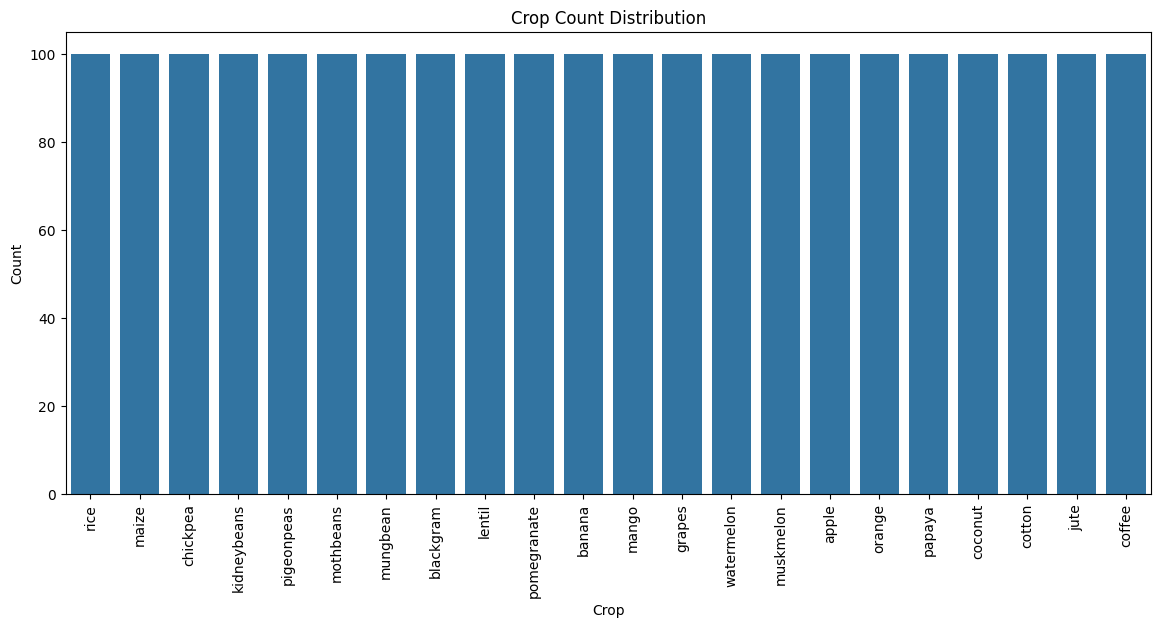

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x="label")
plt.title("Crop Count Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

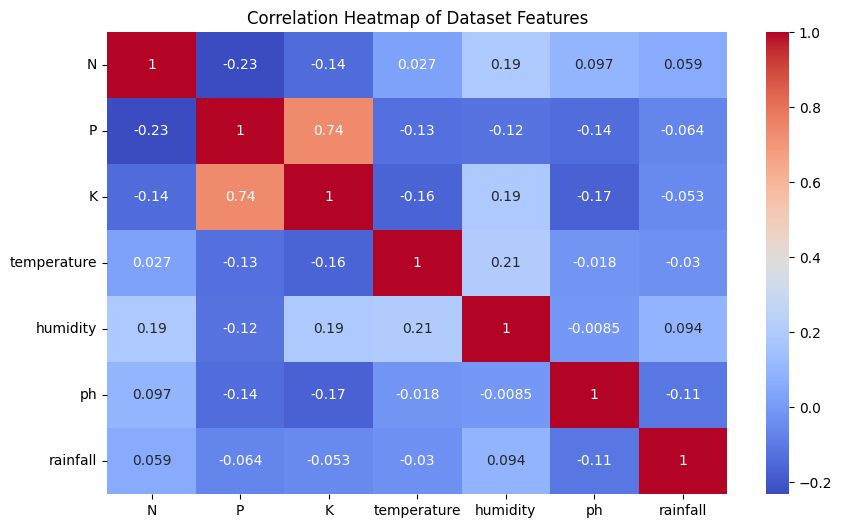

In [ ]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop("label", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Dataset Features")
plt.show()

In [ ]:
# Separate input features and target output

X = df.drop("label", axis=1)
y = df["label"]

print("Input Features:")
print(X.head())

print("\nTarget Output:")
print(y.head())

Input Features:
    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340

Target Output:
0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object


In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1760, 7)
Testing Data Shape: (440, 7)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [ ]:
from sklearn.metrics import accuracy_score

# Predict crop labels for testing data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy Percentage:", accuracy * 100)

Model Accuracy: 0.9931818181818182
Model Accuracy Percentage: 99.31818181818181


In [ ]:
from sklearn.metrics import classification_report

# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
    

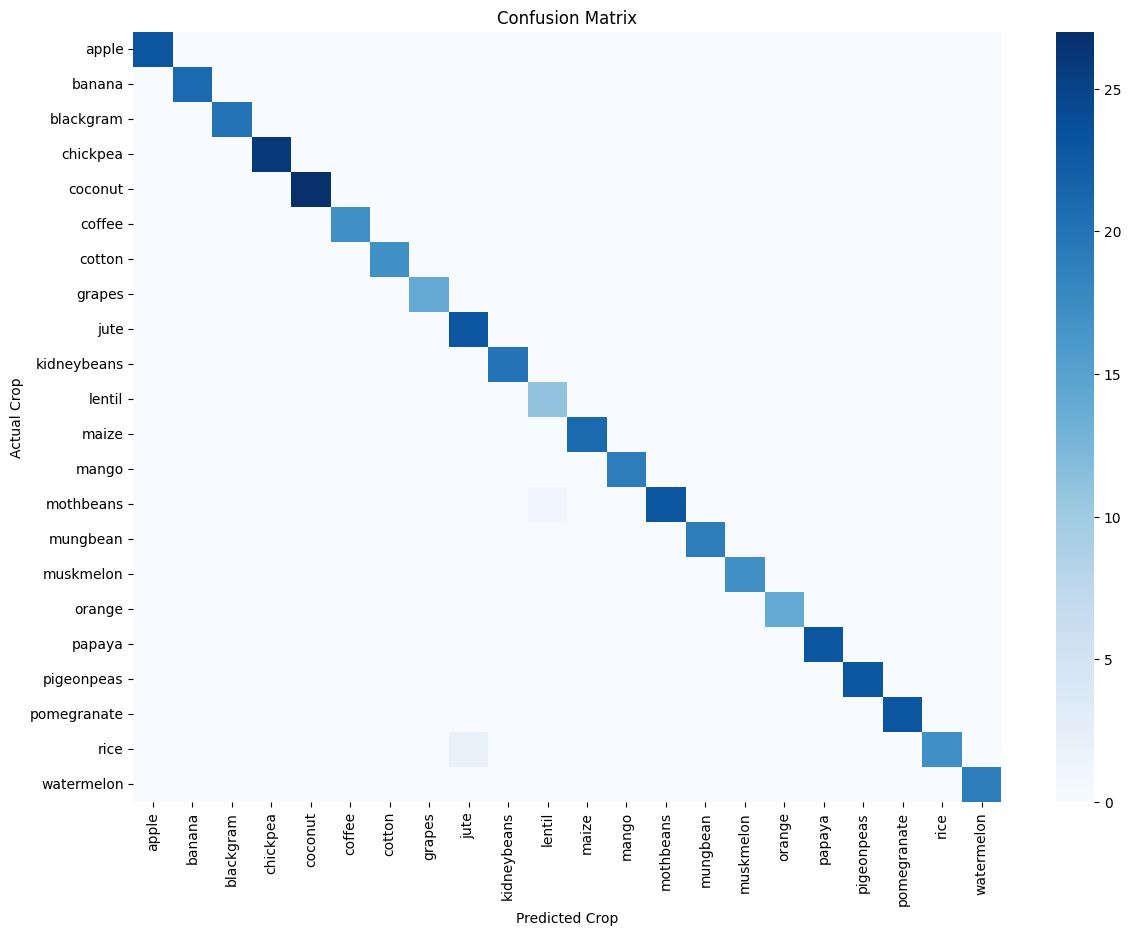

In [ ]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [ ]:
# Feature importance from Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

       Feature  Importance
6     rainfall    0.227036
4     humidity    0.211279
2            K    0.181222
1            P    0.143622
0            N    0.108859
3  temperature    0.075682
5           ph    0.052301


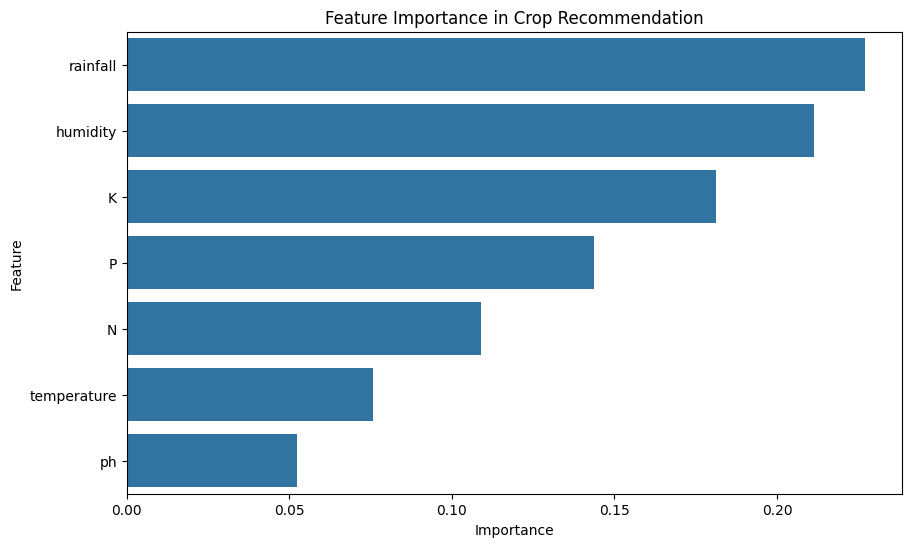

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance in Crop Recommendation")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
# Sample input for crop prediction

sample_input = pd.DataFrame(
    [[90, 42, 43, 20.8, 82, 6.5, 202]],
    columns=X.columns
)

predicted_crop = model.predict(sample_input)

print("Sample Input:")
print(sample_input)

print("\nRecommended Crop:", predicted_crop[0])

Sample Input:
    N   P   K  temperature  humidity   ph  rainfall
0  90  42  43         20.8        82  6.5       202

Recommended Crop: rice


In [ ]:
# Function to recommend crop based on user input

def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):
    input_data = pd.DataFrame(
        [[N, P, K, temperature, humidity, ph, rainfall]],
        columns=X.columns
    )

    prediction = model.predict(input_data)
    return prediction[0]


# Example usage
crop = recommend_crop(
    N=90,
    P=42,
    K=43,
    temperature=20.8,
    humidity=82,
    ph=6.5,
    rainfall=202
)

print("Recommended Crop:", crop)

Recommended Crop: rice


## 6. Results and Discussions

The Random Forest Classifier was trained using 80% of the dataset and tested using 20% of the dataset. The model predicted the crop label based on soil nutrients and environmental conditions.

### Model Performance

The model achieved high accuracy on the testing dataset.

* Algorithm Used: Random Forest Classifier
* Training Data: 80%
* Testing Data: 20%
* Accuracy: 99.31%

### Evaluation Metrics

The model was evaluated using:

* Accuracy Score
* Classification Report
* Confusion Matrix
* Feature Importance

The classification report shows precision, recall, and F1-score for different crop categories. The confusion matrix helps compare actual crop labels with predicted crop labels.

### Feature Importance

Feature importance analysis was used to understand which input factors affected crop prediction the most. Features such as rainfall, humidity, nitrogen, phosphorus, potassium, temperature, and pH helped the model recommend suitable crops.

### Strengths

* The model gives fast crop recommendations.
* Random Forest provides high accuracy for classification problems.
* The system uses important soil and weather parameters.
* The project is simple and useful for agriculture-based decision making.

### Limitations and Future Improvements

* The system depends on the quality of the dataset.
* It does not include real-time weather data.
* It does not consider market price, crop disease, irrigation, or farmer budget.
* The model is trained only on the available crop categories in the dataset.
* **Future Improvement**: The dataset used in this project is taken from Kaggle and is not real-time field data. In future, the system can be improved by using real-time weather data, soil data, and government agriculture datasets to make crop recommendations more practical for farmers.

### Challenges Faced

* Understanding the dataset features.
* Downloading the dataset directly from Kaggle.
* Selecting a suitable Machine Learning algorithm.
* Interpreting evaluation metrics and graphs.

### Learning Outcomes

Through this project, I learned about supervised learning, classification algorithms, dataset analysis, model training, accuracy evaluation, confusion matrix, and feature importance in Machine Learning.

## 7. Conclusion

This project successfully developed an AI-Based Crop Recommendation System using Machine Learning. The system recommends a suitable crop based on soil nutrients and environmental conditions such as Nitrogen, Phosphorus, Potassium, temperature, humidity, pH, and rainfall.

The Random Forest Classifier was used for crop prediction because it performs well on classification problems and provides high accuracy. The model was trained and tested using the Crop Recommendation Dataset, and it produced accurate crop recommendations for sample input values.

This project shows how Artificial Intelligence can be applied in agriculture to support better decision making. It can help farmers choose suitable crops based on available soil and weather conditions, which may improve productivity and reduce crop selection mistakes.


## 8. References

1. Crop Recommendation Dataset by Atharva Ingle, Kaggle: atharvaingle/crop-recommendation-dataset
2. Scikit-learn Documentation.
3. Pandas Documentation.
4. NumPy Documentation.
5. Matplotlib Documentation.
6. Seaborn Documentation.
7. Google Colab.
8. KaggleHub Python Library.

## Appendix

The appendix contains supporting materials related to the project implementation.

### Screenshots to Include in Final Report

1. Dataset downloaded from Kaggle using KaggleHub
2. First five rows of the dataset
3. Dataset shape, columns, and missing values
4. Statistical summary of the dataset
5. Crop count distribution graph
6. Correlation heatmap
7. Training and testing data split
8. Model accuracy output
9. Classification report
10. Confusion matrix
11. Feature importance graph
12. Sample crop prediction output
13. GitHub repository screenshot

### Sample Output

For the sample input:

* Nitrogen = 90
* Phosphorus = 42
* Potassium = 43
* Temperature = 20.8
* Humidity = 82
* pH = 6.5
* Rainfall = 202

The model recommended the crop as:

Rice
